In [2]:
# Gerekli veri analizi ve makine öğrenimi kütüphanelerini içe aktarma
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


In [4]:
# Kolon isimlerini el ile tanımlıyoruz
kolonlar = [
    'TedarikciNo', 'TedarikciAdi', 'TedarikciSegmenti', 
    'ToplamTeslimat', 'ZamanindaTeslimat', 'OTD_Orani', 
    'SiparisSayisi', 'ToplamSiparisTutari', 'AcikTutar'
]

# CSV dosyasını okuma
df = pd.read_csv(
    'vendor_analytics_data.csv', 
    sep=';', 
    names=kolonlar, 
    header=None, 
    encoding='utf-8-sig'
)

# İlk satırları inceleyelim
df.head()

,TedarikciNo,TedarikciAdi,TedarikciSegmenti,ToplamTeslimat,ZamanindaTeslimat,OTD_Orani,SiparisSayisi,ToplamSiparisTutari,AcikTutar
0,VEND-CN01,NovaTech Components Ltd.,A (Güvenilir),7,6,"85,71",2,812800.0,174600.0
1,VEND-DE01,Alfa Elektronik B.V.,B (İzlenmeli),3,2,"66,67",2,731500.0,315000.0
2,VEND-TR01,TeknoTedarik Dagitim A.S.,B (İzlenmeli),4,3,75,3,3144000.0,1338500.0
3,VEND-TR02,Kuzey Bilisim Sistemleri Ltd. Sti.,C (Kritik / Riskli),2,1,50,2,1234000.0,811000.0
4,VEND-TR03,Ege Teknoloji Lojistik A.S.,A (Güvenilir),2,2,100,1,775000.0,277500.0


In [6]:
# OTD oranındaki virgülü noktaya çevirip float yapma
df['OTD_Orani'] = df['OTD_Orani'].astype(str).str.replace(',', '.').astype(float)

# Sayısal alanların tip dönüşümleri
df['ToplamSiparisTutari'] = df['ToplamSiparisTutari'].astype(float)
df['AcikTutar'] = df['AcikTutar'].astype(float)
df['SiparisSayisi'] = df['SiparisSayisi'].astype(int)

# Veri tiplerini ve eksik değer olup olmadığını kontrol edelim
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TedarikciNo          7 non-null      object 
 1   TedarikciAdi         7 non-null      object 
 2   TedarikciSegmenti    7 non-null      object 
 3   ToplamTeslimat       7 non-null      int64  
 4   ZamanindaTeslimat    7 non-null      int64  
 5   OTD_Orani            7 non-null      float64
 6   SiparisSayisi        7 non-null      int32  
 7   ToplamSiparisTutari  7 non-null      float64
 8   AcikTutar            7 non-null      float64
dtypes: float64(3), int32(1), int64(2), object(3)
memory usage: 608.0+ bytes


In [8]:
# 1. Kriter: Gecikme Oranı (% OTD Sapması)
df['Gecikme_Orani'] = (100 - df['OTD_Orani']) / 100

# 2. ve 3. Kriter: Min-Max Normalizasyonu (0 - 1 aralığı)
scaler = MinMaxScaler()
df['Norm_Acik_Tutar'] = scaler.fit_transform(df[['AcikTutar']])
df['Norm_Siparis_Sayisi'] = scaler.fit_transform(df[['SiparisSayisi']])

# Bileşik Risk Skoru Hesaplama (0 - 100 Puan)
df['Risk_Skoru'] = (
    (df['Gecikme_Orani'] * 0.40) +
    (df['Norm_Acik_Tutar'] * 0.35) +
    (df['Norm_Siparis_Sayisi'] * 0.25)
) * 100

df['Risk_Skoru'] = df['Risk_Skoru'].round(2)

print("Risk skorları başarıyla hesaplandı.")

Risk skorları başarıyla hesaplandı.


In [10]:
# Skor aralıklarına göre risk kategorisi atama
def risk_kategorisi(skor):
    if skor >= 60:
        return 'Yüksek Risk (High Risk)'
    elif skor >= 35:
        return 'Orta Risk (Medium Risk)'
    else:
        return 'Düşük Risk (Low Risk)'

df['Risk_Kategorisi'] = df['Risk_Skoru'].apply(risk_kategorisi)

# Sonuçları en riskliden en düşüğe doğru sıralayalım
rapor = df[[
    'TedarikciAdi', 'TedarikciSegmenti', 'OTD_Orani', 
    'AcikTutar', 'Risk_Skoru', 'Risk_Kategorisi'
]].sort_values(by='Risk_Skoru', ascending=False)

rapor

,TedarikciAdi,TedarikciSegmenti,OTD_Orani,AcikTutar,Risk_Skoru,Risk_Kategorisi
2,TeknoTedarik Dagitim A.S.,B (İzlenmeli),75.00,1338500.0,70.00,Yüksek Risk (High Risk)
3,Kuzey Bilisim Sistemleri Ltd. Sti.,C (Kritik / Riskli),50.00,811000.0,53.71,Orta Risk (Medium Risk)
1,Alfa Elektronik B.V.,B (İzlenmeli),66.67,315000.0,34.07,Düşük Risk (Low Risk)
0,NovaTech Components Ltd.,A (Güvenilir),85.71,174600.0,22.78,Düşük Risk (Low Risk)
6,Pine Valley Systems Inc.,C (Kritik / Riskli),50.00,78000.0,22.04,Düşük Risk (Low Risk)
5,Atlas Komponent Sanayi A.S.,C (Kritik / Riskli),50.00,0.0,20.00,Düşük Risk (Low Risk)
4,Ege Teknoloji Lojistik A.S.,A (Güvenilir),100.00,277500.0,7.26,Düşük Risk (Low Risk)


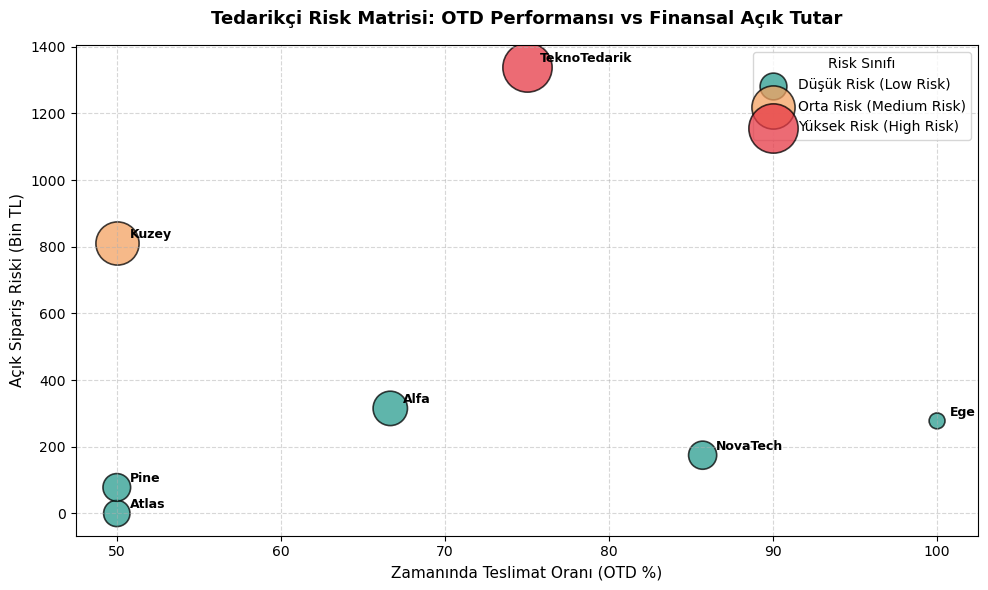

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

renkler = {
    'Yüksek Risk (High Risk)': '#E63946',
    'Orta Risk (Medium Risk)': '#F4A261',
    'Düşük Risk (Low Risk)': '#2A9D8F'
}

# Her risk kategorisini ayrı renkle çizme
for kat, grup in df.groupby('Risk_Kategorisi'):
    plt.scatter(
        grup['OTD_Orani'], 
        grup['AcikTutar'] / 1000, 
        s=grup['Risk_Skoru'] * 18, 
        label=kat, 
        color=renkler[kat], 
        alpha=0.75, 
        edgecolors='black',
        linewidth=1.2
    )

# Tedarikçi isim etiketlerini yerleştirme
for _, row in df.iterrows():
    kisa_ad = row['TedarikciAdi'].split()[0]
    plt.annotate(
        kisa_ad, 
        (row['OTD_Orani'] + 0.8, (row['AcikTutar'] / 1000) + 15), 
        fontsize=9, 
        fontweight='semibold'
    )

plt.title('Tedarikçi Risk Matrisi: OTD Performansı vs Finansal Açık Tutar', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Zamanında Teslimat Oranı (OTD %)', fontsize=11)
plt.ylabel('Açık Sipariş Riski (Bin TL)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Risk Sınıfı', loc='upper right')

plt.tight_layout()
plt.savefig('vendor_risk_matrix.png', dpi=300)
plt.show()

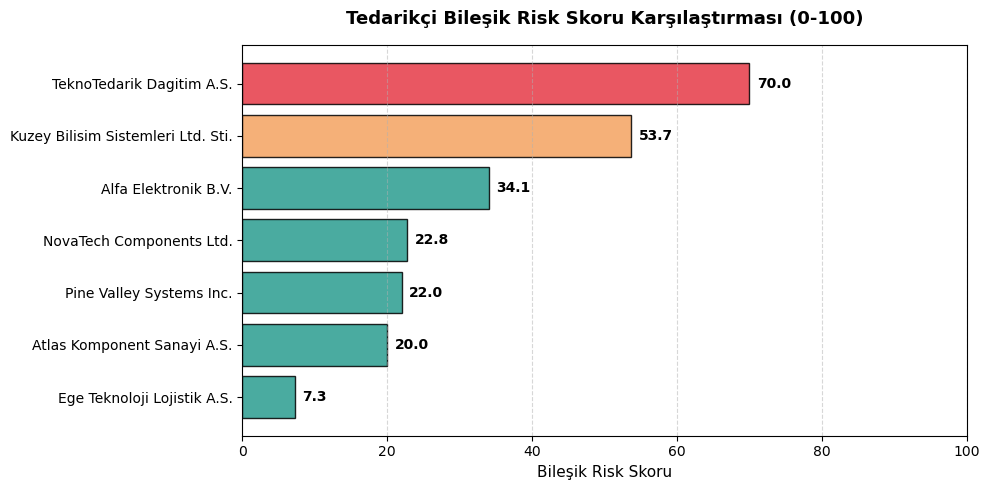

In [14]:
# Sıralı çubuk grafik
plt.figure(figsize=(10, 5))

sirali_df = df.sort_values(by='Risk_Skoru', ascending=True)
bar_colors = [renkler[kat] for kat in sirali_df['Risk_Kategorisi']]

bars = plt.barh(sirali_df['TedarikciAdi'], sirali_df['Risk_Skoru'], color=bar_colors, edgecolor='black', alpha=0.85)

# Çubukların üzerine skorları yazdırma
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}', va='center', fontsize=10, fontweight='bold')

plt.title('Tedarikçi Bileşik Risk Skoru Karşılaştırması (0-100)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Bileşik Risk Skoru', fontsize=11)
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('vendor_risk_ranking.png', dpi=300)
plt.show()

In [16]:
# Nihai risk analiz tablosunu CSV olarak kaydetme
rapor.to_csv('vendor_risk_analysis_output.csv', index=False, encoding='utf-8-sig')

print("Dosya başarıyla 'vendor_risk_analysis_output.csv' adıyla kaydedildi!")

Dosya başarıyla 'vendor_risk_analysis_output.csv' adıyla kaydedildi!
